# 02 · Evaluación del modelo — Detección de fraude

Cargamos el modelo entrenado (`models/model.joblib`) y lo evaluamos sobre el
**test** (`data/processed/test.parquet`), que conserva la distribución real
(~1% fraude)

> correr antes `./.venv/bin/python -m fraud.features` y
> `./.venv/bin/python -m fraud.modeling.train`.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

from fraud.config import MODELS_DIR, PROCESSED_DATA_DIR
from fraud.features import FEATURES, TARGET

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 12,
})
COLOR = "#0072B2"        # azul
COLOR_ALT = "#D55E00"    # naranja
GRAY = "#999999"

artifact = joblib.load(MODELS_DIR / "model.joblib")
pipeline = artifact["pipeline"]
print("Versión del modelo:", artifact["version"])

test = pd.read_parquet(PROCESSED_DATA_DIR / "test.parquet")
X_test, y_test = test[FEATURES], test[TARGET]
proba = pipeline.predict_proba(X_test)[:, 1]
pred = pipeline.predict(X_test)

2026-09-04 20:34:43.537 | INFO     | fraud.config:<module>:11 - PROJ_ROOT path is: /Users/prisci/Documents/MIA/repo/fraud-detection


Versión del modelo: 1.0.0


## Resumen de métricas

Clases desbalanceadas, **PR-AUC** y **recall de fraude** importan más que accuracy

In [2]:
print(f"ROC-AUC : {roc_auc_score(y_test, proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, proba):.4f}")
print()
print(classification_report(y_test, pred, target_names=["legit", "fraud"]))

ROC-AUC : 0.9942
PR-AUC  : 0.9149

              precision    recall  f1-score   support

       legit       1.00      1.00      1.00     11884
       fraud       0.85      0.86      0.86       116

    accuracy                           1.00     12000
   macro avg       0.93      0.93      0.93     12000
weighted avg       1.00      1.00      1.00     12000



## 1. Confusion matrix

Cuántos fraudes atrapa (TP), cuántos se escapan (FN) y cuántas falsas alarmas (FP).

Con datos desbalanceados, mostramos la matriz normalizada.. cada fila suma 1 y la diagonal es el **recall por clase**.
El valor abajo-derecha es el recall de fraude.

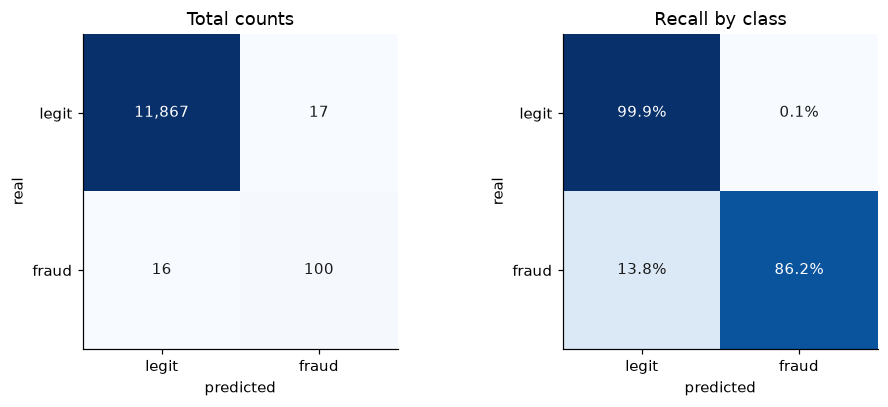

In [2]:
cm = confusion_matrix(y_test, pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True)  # normalizar por fila (clase real)
labels = ["legit", "fraud"]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
panels = [
    (axes[0], cm, "Total counts", "{:,}", cm.max()),
    (axes[1], cm_norm, "Recall by class", "{:.1%}", 1.0),
]
for ax, mat, title, fmt, vmax in panels:
    ax.grid(False)
    ax.imshow(mat, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks([0, 1], labels)
    ax.set_yticks([0, 1], labels)
    ax.set_xlabel("predicted")
    ax.set_ylabel("real")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            val = mat[i, j]
            color = "white" if val > vmax * 0.5 else "#1a1a1a"
            ax.text(j, i, fmt.format(val), ha="center", va="center", color=color)

fig.tight_layout()
plt.show()

## 2. Curva ROC

Compromiso entre verdaderos positivos y falsos positivos a todos los umbrales.

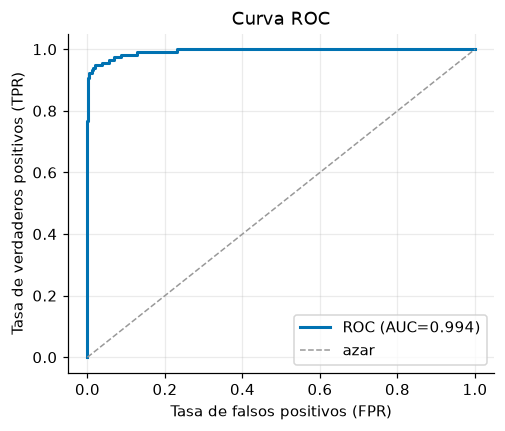

In [4]:
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, color=COLOR, linewidth=2, label=f"ROC (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], color=GRAY, linestyle="--", linewidth=1, label="azar")
ax.set_xlabel("Tasa de falsos positivos (FPR)")
ax.set_ylabel("Tasa de verdaderos positivos (TPR)")
ax.set_title("Curva ROC")
ax.legend(loc="lower right")
plt.show()

## 3. Curva Precision-Recall

Más informativa con datos desbalanceados. La línea punteada es el baseline
(un modelo que predice al azar acierta = tasa de fraude).

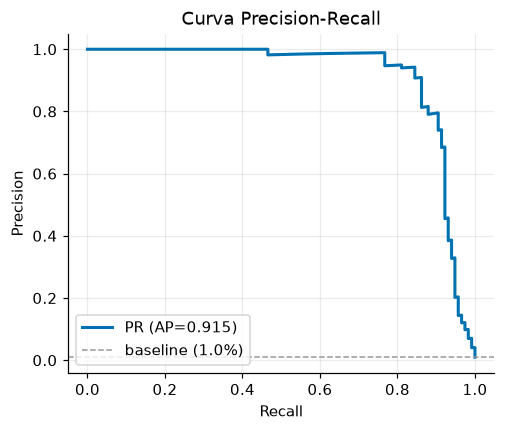

In [5]:
prec, rec, _ = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
baseline = y_test.mean()

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rec, prec, color=COLOR, linewidth=2, label=f"PR (AP={ap:.3f})")
ax.axhline(baseline, color=GRAY, linestyle="--", linewidth=1, label=f"baseline ({baseline:.1%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall")
ax.legend(loc="lower left")
plt.show()

## 4. Precision y Recall según el umbral

El umbral por defecto es 0.5, pero podés moverlo según el negocio: subir recall
(atrapar más fraude, más falsas alarmas) o subir precision (menos falsas alarmas).

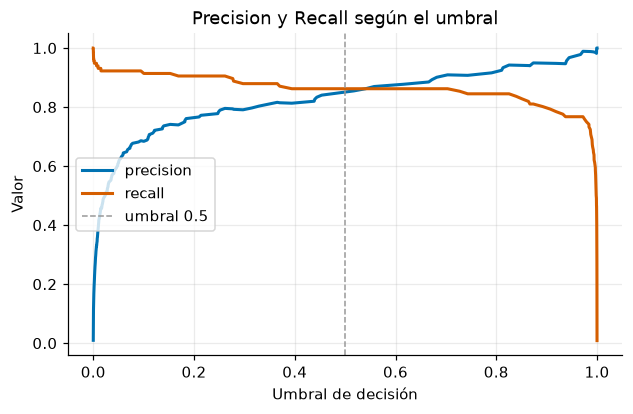

In [6]:
prec, rec, thr = precision_recall_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(thr, prec[:-1], color=COLOR, linewidth=2, label="precision")
ax.plot(thr, rec[:-1], color=COLOR_ALT, linewidth=2, label="recall")
ax.axvline(0.5, color=GRAY, linestyle="--", linewidth=1, label="umbral 0.5")
ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Valor")
ax.set_title("Precision y Recall según el umbral")
ax.legend(loc="center left")
plt.show()

## 5. Importancia de features (XGBoost)

Qué variables pesan más en la decisión del modelo.

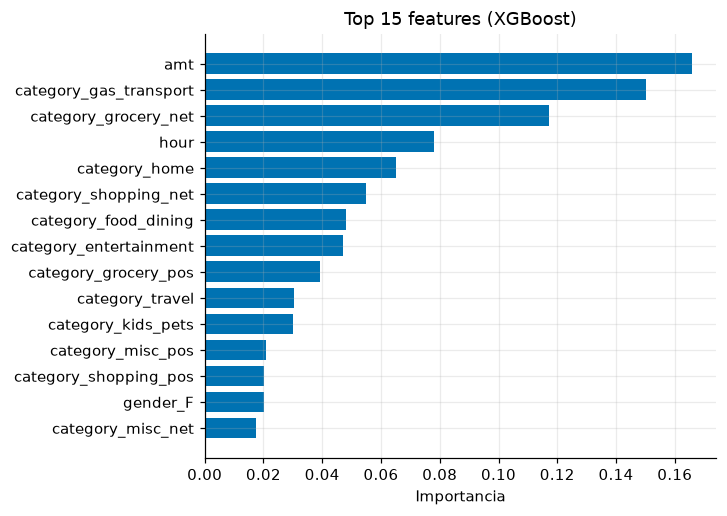

In [7]:
prep = pipeline.named_steps["prep"]
clf = pipeline.named_steps["clf"]
names = [n.replace("cat__", "").replace("remainder__", "") for n in prep.get_feature_names_out()]
importances = pd.Series(clf.feature_importances_, index=names).sort_values().tail(15)

fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(importances.index, importances.values, color=COLOR)
ax.set_xlabel("Importancia")
ax.set_title("Top 15 features (XGBoost)")
plt.show()

## Conclusiones

- Sobre el test con distribución real, el modelo atrapa la mayoría de los
  fraudes con buena precision (ver matriz y reporte).
- La **PR-AUC** es la métrica de referencia por el desbalance.
- El **umbral** es una perilla de negocio: movelo según cuánto te cuesta un
  fraude no detectado vs una falsa alarma.
- La importancia de features confirma lo que vimos en el EDA (`amt` manda).